# 233. Number of Digit One
https://leetcode.com/problems/number-of-digit-one/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Digit-by-digit math | $O(\log n)$ | $O(1)$ | Optimal — count 1s at each position |
| Brute force | $O(n \log n)$ | $O(1)$ | Count digit 1 in every number |

## Methodology

For each digit position (ones, tens, hundreds, ...), count how many times digit 1 appears at that position across all numbers from 1 to n. For a position with factor `f` (1, 10, 100, ...), split `n` into `high = n / (f*10)`, `cur = (n / f) % 10`, and `low = n % f`. If `cur == 0`, the count is `high * f`. If `cur == 1`, it is `high * f + low + 1`. If `cur >= 2`, it is `(high + 1) * f`. Sum across all positions.

## Solutions

### C#

In [ ]:
public class Solution {
    public int CountDigitOne(int n) {
        int count = 0;
        for (long f = 1; f <= n; f *= 10) {
            long high = n / (f * 10);
            long cur = (n / f) % 10;
            long low = n % f;
            if (cur == 0)
                count += (int)(high * f);
            else if (cur == 1)
                count += (int)(high * f + low + 1);
            else
                count += (int)((high + 1) * f);
        }
        return count;
    }
}

### Python

In [ ]:
class Solution:
    def countDigitOne(self, n: int) -> int:
        count = 0
        f = 1
        while f <= n:
            high = n // (f * 10)
            cur = (n // f) % 10
            low = n % f
            if cur == 0:
                count += high * f
            elif cur == 1:
                count += high * f + low + 1
            else:
                count += (high + 1) * f
            f *= 10
        return count

### Go

In [ ]:
func countDigitOne(n int) int {
    count := 0
    for f := 1; f <= n; f *= 10 {
        high := n / (f * 10)
        cur := (n / f) % 10
        low := n % f
        if cur == 0 {
            count += high * f
        } else if cur == 1 {
            count += high*f + low + 1
        } else {
            count += (high + 1) * f
        }
    }
    return count
}

### Rust

In [ ]:
impl Solution {
    pub fn count_digit_one(n: i32) -> i32 {
        let n = n as i64;
        let mut count: i64 = 0;
        let mut f: i64 = 1;
        while f <= n {
            let high = n / (f * 10);
            let cur = (n / f) % 10;
            let low = n % f;
            count += match cur {
                0 => high * f,
                1 => high * f + low + 1,
                _ => (high + 1) * f,
            };
            f *= 10;
        }
        count as i32
    }
}

## Example Scenarios

1. **Common Case** — Small two-digit number  
   **Input:** `n = 13`  
   Numbers containing digit 1: $1, 10, 11$ (two 1s), $12, 13$. Units place contributes $2$ ones ($1, 11$), tens place contributes $4$ ones ($10, 11, 12, 13$). Total = $6$.

2. **Slightly Complex** — Three-digit number with carries  
   **Input:** `n = 301`  
   For factor $f=1$ (units): high $= 30$, cur $= 1$, low $= 0$ → count $+= 30 \times 1 + 0 + 1 = 31$. For $f=10$ (tens): high $= 3$, cur $= 0$ → count $+= 3 \times 10 = 30$. For $f=100$ (hundreds): high $= 0$, cur $= 3$ → count $+= (0+1) \times 100 = 100$. Total $= 161$.

3. **Edge Case: Time Factor** — Maximum value  
   **Input:** `n = 2 \times 10^9$  
   The loop runs once per decimal digit: $\lceil\log_{10}(2 \times 10^9)\rceil = 10$ iterations. Each iteration does $O(1)$ math. Even at the constraint maximum, computation is essentially instant.

4. **Edge Case: Space Factor** — Minimal input  
   **Input:** `n = 1`  
   Only one number to consider. Factor $f=1$: high $= 0$, cur $= 1$, low $= 0$. Count $= 0 \times 1 + 0 + 1 = 1$. The algorithm uses $O(1)$ space regardless of input size.

5. **Almost-Impossible but Plausible** — Boundary at $2{,}147{,}483{,}647$  
   **Input:** `n = 2147483647` (INT\_MAX)  
   The factor variable must use 64-bit arithmetic since $f$ can exceed $2^{31}$ during the loop. With 10 digits, there are exactly 10 loop iterations. The answer is $2{,}071{,}027{,}783$ — nearly $n$ itself, because the digit 1 appears frequently across $2.1$ billion numbers.

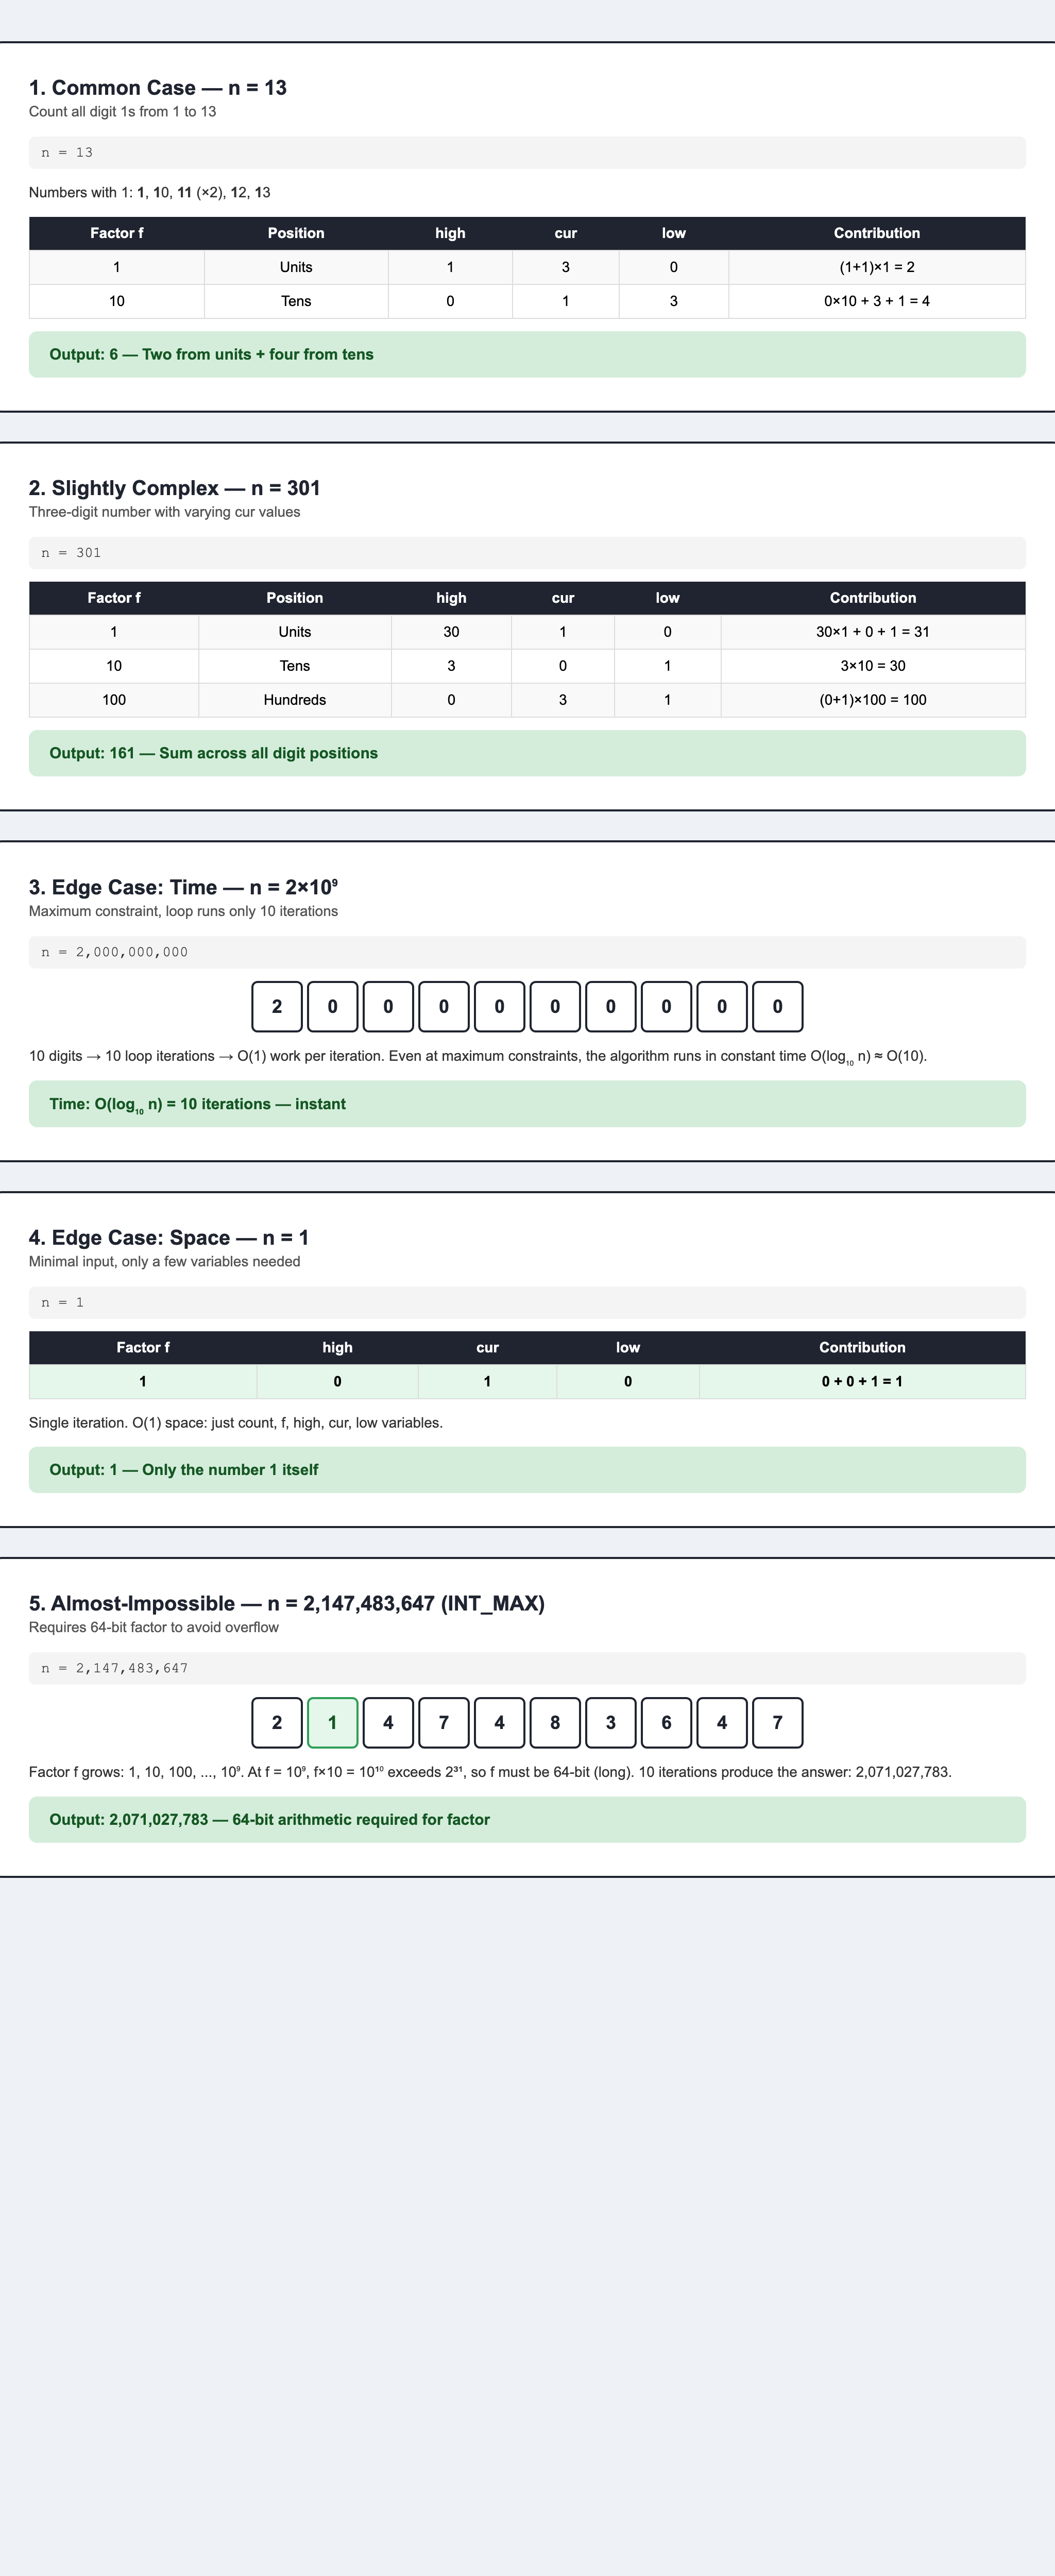